# Metacatalog anomaly detection

Classical (**numpy**) Mahalanobis outlier scoring on selected columns of a loaded
metacatalog. Load a catalog tree, optionally apply `QUALITY_FLAG_MASK` and
`RADIO_QA_FILTER`, then **Run** scoring.

**Complete-case (default):** only rows with finite values in every selected column
define the mean/covariance and receive a \(d^2\) score. Incomplete rows are unscored.

**Optional median impute:** fit still uses complete cases only; missing selected
features are filled with complete-case column medians so those rows can be scored.
Rows missing *all* selected features stay unscored.

Defaults prefer: `origin_band` (factorized), `n_lst_contributions`, `Peak_flux_82MHz`,
`Total_flux_82MHz`, `Maj`, `Min`, `spec_model_a0`–`a3`, `spec_model_n_flux`,
`spec_model_n_terms` (intersection with columns present on the loaded table).

The \(d^2\) histogram uses a **log-x** scale. Click an outliers-table row to highlight
that `meta_id` on the plots and show the source row below. For interactive sky /
spectrum / trace inspection, open the same `meta_id` in `metacatalog_query.ipynb`.

Requires `lwa-catalog` (core) plus `lwa-catalog[viz]` for Panel widgets.

**Run cells in order.**


In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import panel as pn

from lwa_catalog.analyze import (
    DEFAULT_MAHALANOBIS_COLUMNS,
    candidate_feature_columns,
    continuous_feature_columns,
    filter_by_quality_mask,
    mahalanobis_outlier_scores,
    resolve_mahalanobis_columns,
)
from lwa_catalog.io import read_metacatalog, read_table, resolve_metacatalog_path
from lwa_catalog.paths import CatalogLayout

# --- user configuration ---------------------------------------------------
CATALOG_DIR = Path("/fast/claw/metacatalog_coaddR-0.75_subband")

# Prefer spectral (has spec_model_*), else quality, else metacatalog.parquet.
# Set CATALOG_FILE to a basename under CATALOG_DIR to override (e.g. metacatalog_radio.parquet).
PREFER_SPECTRAL = True
PREFER_QUALITY = True
CATALOG_FILE: str | None = None  # e.g. "metacatalog_spectral.parquet"

# Default metacatalog row filter (quality_flag & mask == 0); None keeps all rows.
# Bits: HAS_NAN|INVALID_ASTROMETRY|UNPHYSICAL_FLUX|RESID_ABS_FAIL|RESID_PCTL_RMS|RESID_PCTL_MEAN|JITTER_FAIL|LARGE_SINGLE
QUALITY_FLAG_MASK = 33267

# Optional row subset after quality mask.
# None | boolean Series | Index | label array | pandas query string.
# RADIO_QA_FILTER = None
# RADIO_QA_FILTER = "n_assoc_NVSS >= 1"
# RADIO_QA_FILTER = "spec_model_chi2_red < 2"
RADIO_QA_FILTER = None


def apply_radio_qa_filter(
    df: pd.DataFrame,
    row_filter: pd.Series | pd.Index | np.ndarray | list | str | None,
) -> pd.DataFrame:
    """Subset *df* with a pandas boolean mask, Index, label array, or query string."""
    if row_filter is None:
        return df.copy()
    if isinstance(row_filter, str):
        return df.query(row_filter).copy()
    if isinstance(row_filter, pd.Series):
        if not pd.api.types.is_bool_dtype(row_filter):
            raise TypeError("RADIO_QA_FILTER Series must be boolean")
        aligned = row_filter.reindex(df.index)
        if aligned.isna().any():
            missing = int(aligned.isna().sum())
            raise ValueError(
                f"RADIO_QA_FILTER boolean Series has {missing} index labels "
                "not present in the catalog"
            )
        return df.loc[aligned.astype(bool)].copy()
    if isinstance(row_filter, pd.Index):
        missing = row_filter.difference(df.index)
        if len(missing):
            raise ValueError(
                f"RADIO_QA_FILTER Index has {len(missing)} labels not in the catalog"
            )
        return df.loc[row_filter].copy()
    labels = pd.Index(row_filter)
    missing = labels.difference(df.index)
    if len(missing):
        raise ValueError(
            f"RADIO_QA_FILTER labels have {len(missing)} entries not in the catalog"
        )
    return df.loc[labels].copy()


def apply_quality_mask_if_configured(df: pd.DataFrame) -> pd.DataFrame:
    if QUALITY_FLAG_MASK is None:
        return df
    return filter_by_quality_mask(df, QUALITY_FLAG_MASK)


layout = CatalogLayout(CATALOG_DIR)
if CATALOG_FILE:
    catalog_path = Path(CATALOG_DIR) / CATALOG_FILE
    if not catalog_path.is_file():
        raise FileNotFoundError(catalog_path)
    df_full = apply_quality_mask_if_configured(read_table(catalog_path, as_pandas=True))
else:
    catalog_path = resolve_metacatalog_path(
        layout,
        prefer_quality=PREFER_QUALITY,
        prefer_spectral=PREFER_SPECTRAL,
    )
    df_full = read_metacatalog(
        layout,
        prefer_quality=PREFER_QUALITY,
        prefer_spectral=PREFER_SPECTRAL,
        quality_mask=QUALITY_FLAG_MASK,
    )

df = apply_radio_qa_filter(df_full, RADIO_QA_FILTER)
if df.empty:
    raise ValueError("Filtered catalog is empty; relax QUALITY_FLAG_MASK / RADIO_QA_FILTER")

print(f"CATALOG_DIR = {CATALOG_DIR.resolve()}")
print(f"catalog_path = {catalog_path.resolve()}")
print(f"QUALITY_FLAG_MASK = {QUALITY_FLAG_MASK}")
print(f"RADIO_QA_FILTER = {RADIO_QA_FILTER!r}")
print(f"rows after quality: {len(df_full):,}")
print(f"rows after RADIO_QA_FILTER: {len(df):,}")
print(f"columns: {len(df.columns)}")

pn.extension("tabulator", throttled=True)


CATALOG_DIR = /fast/claw/metacatalog_coaddR-0.75_subband
catalog_path = /fast/claw/metacatalog_coaddR-0.75_subband/metacatalog_spectral.parquet
QUALITY_FLAG_MASK = 33267
RADIO_QA_FILTER = None
rows after quality: 128,352
rows after RADIO_QA_FILTER: 128,352
columns: 140


## Optional interactive `RADIO_QA_FILTER`

Edit the query and click **Apply filter** to update `df` without reloading the Parquet.
Then re-run the Mahalanobis cell (or click **Run** there) so scores match the new subset.


In [2]:
_radio_qa_w = pn.widgets.TextInput(
    name="RADIO_QA_FILTER",
    value=(RADIO_QA_FILTER if isinstance(RADIO_QA_FILTER, str) else ""),
    placeholder='e.g. n_assoc_NVSS >= 1',
    sizing_mode="stretch_width",
)
_radio_qa_status = pn.pane.Markdown(
    f"Using **{len(df):,}** / **{len(df_full):,}** rows."
)


def _publish_df(new_df: pd.DataFrame, *, note: str = "") -> None:
    global df, RADIO_QA_FILTER
    df = new_df
    extra = f" {note}" if note else ""
    _radio_qa_status.object = (
        f"Using **{len(df):,}** / **{len(df_full):,}** rows "
        f"(filter=`{RADIO_QA_FILTER!r}`).{extra}"
    )


def _on_apply_radio_qa(_event=None) -> None:
    global RADIO_QA_FILTER
    text = (_radio_qa_w.value or "").strip()
    RADIO_QA_FILTER = text or None
    try:
        filtered = apply_radio_qa_filter(df_full, RADIO_QA_FILTER)
    except Exception as exc:
        _radio_qa_status.object = f"**RADIO_QA_FILTER failed:** `{exc}`"
        return
    if filtered.empty and RADIO_QA_FILTER is not None:
        _publish_df(filtered, note="_Empty — relax the filter._")
        return
    _publish_df(filtered)


def _on_clear_radio_qa(_event=None) -> None:
    global RADIO_QA_FILTER
    RADIO_QA_FILTER = None
    _radio_qa_w.value = ""
    _publish_df(df_full.copy())


_apply_btn = pn.widgets.Button(name="Apply filter", button_type="primary", width=120)
_clear_btn = pn.widgets.Button(name="Clear", width=80)
_apply_btn.on_click(_on_apply_radio_qa)
_clear_btn.on_click(_on_clear_radio_qa)

pn.Column(
    pn.Row(_radio_qa_w, _apply_btn, _clear_btn, align="end"),
    _radio_qa_status,
)


Column
    [0] Row(align='end')
        [0] TextInput(label='RADIO_QA_FILTER', name='RADIO_QA_FILTER', placeholder='e.g. n_assoc_NVSS >= 1', sizing_mode='stretch_width')
        [1] Button(button_type='primary', color='primary', label='Apply filter', name='Apply filter', width=120)
        [2] Button(label='Clear', name='Clear', width=80)
    [1] Markdown(str)

## Mahalanobis outliers

Choose feature columns, set the high-tail percentile, optionally enable median impute,
then click **Run**. Results use the current `df` (quality + `RADIO_QA_FILTER`).


Column
    [0] Markdown(str)
    [1] MultiChoice(label='Feature columns', name='Feature columns', options=['origin_band', ...], sizing_mode='stretch_width', solid=False, value=['origin_band', ...])
    [2] Row(align='end')
        [0] FloatInput(end=100.0, label='Percentile (high tail)', name='Percentile (high tail)', start=50.0, step=0.5, value=99.0, width=160)
        [1] Checkbox(label='Score incomplete r..., name='Score incomplete r...)
        [2] Button(button_type='primary', color='primary', label='Run', name='Run', width=100)
    [3] Markdown(str)
    [4] Markdown(str)
    [5] Tabulator(height=320, page_size=25, pagination='local', show_index=False, sizing_mode='stretch_width', value=Empty DataFrame
Columns: [...)
    [6] Markdown(str)
    [7] Tabulator(disabled=True, height=140, show_index=False, sizing_mode='stretch_width', value=Empty DataFrame
Columns: [...)
    [8] Row
        [0] Matplotlib(Figure, sizing_mode='stretch_width', tight=True)
        [1] Matplotlib(Figure, sizing_mode='stretch_width', tight=True)
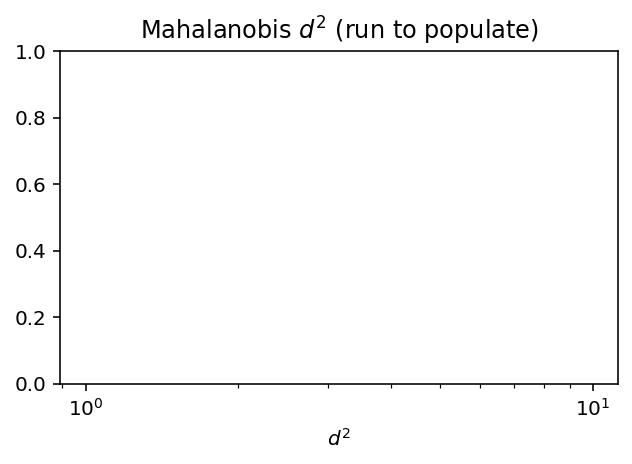
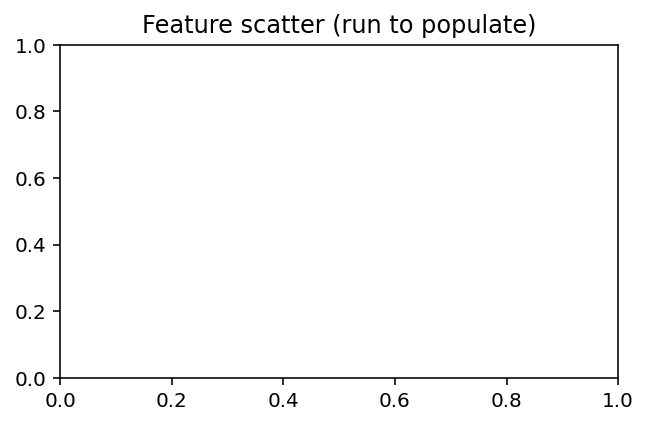

In [3]:
from __future__ import annotations

import re

import matplotlib.pyplot as plt

mahalanobis_result = None
_mahalanobis_selected_meta_id: int | None = None

_status = pn.pane.Markdown("Click **Run** to score the current `df`.")
_outlier_table = pn.widgets.Tabulator(
    pd.DataFrame(),
    sizing_mode="stretch_width",
    height=320,
    disabled=False,
    selectable=1,
    pagination="local",
    page_size=25,
    show_index=False,
)
_selected_row_table = pn.widgets.Tabulator(
    pd.DataFrame(),
    sizing_mode="stretch_width",
    height=140,
    disabled=True,
    pagination=None,
    show_index=False,
)
_hist_pane = pn.pane.Matplotlib(plt.figure(figsize=(5, 3)), tight=True, sizing_mode="stretch_width")
_scatter_pane = pn.pane.Matplotlib(plt.figure(figsize=(5, 3)), tight=True, sizing_mode="stretch_width")
plt.close("all")


def _require_df() -> pd.DataFrame | None:
    frame = globals().get("df")
    if frame is None or not isinstance(frame, pd.DataFrame) or frame.empty:
        _status.object = "_`df` is empty; load a catalog and relax filters first._"
        return None
    return frame


def _blank_figures() -> tuple:
    fig_h, ax_h = plt.subplots(figsize=(5, 3))
    ax_h.set_title("Mahalanobis $d^2$ (run to populate)")
    ax_h.set_xlabel(r"$d^2$")
    ax_h.set_xscale("log")
    fig_s, ax_s = plt.subplots(figsize=(5, 3))
    ax_s.set_title("Feature scatter (run to populate)")
    return fig_h, fig_s


def _update_plots(
    result,
    frame: pd.DataFrame,
    *,
    selected_meta_id: int | None = None,
) -> None:
    scored = result.distances.notna()
    d2 = result.distances.loc[scored].to_numpy(dtype=float)
    out_flags = result.outlier.loc[scored].to_numpy(dtype=bool)
    scored_index = frame.index[scored.to_numpy()]

    selected_d2 = None
    selected_xy = None
    if selected_meta_id is not None and "meta_id" in frame.columns:
        hit = frame.loc[scored_index]
        hit = hit.loc[hit["meta_id"] == selected_meta_id]
        if len(hit):
            idx0 = hit.index[0]
            selected_d2 = float(result.distances.loc[idx0])
            cont_tmp = continuous_feature_columns(list(result.columns))
            if len(cont_tmp) >= 2:
                selected_xy = (
                    float(pd.to_numeric(hit.iloc[0][cont_tmp[0]], errors="coerce")),
                    float(pd.to_numeric(hit.iloc[0][cont_tmp[1]], errors="coerce")),
                )

    fig_h, ax_h = plt.subplots(figsize=(5.5, 3.2))
    positive = d2[np.isfinite(d2) & (d2 > 0)]
    if len(positive):
        n_bins = min(40, max(10, len(positive) // 5))
        lo = float(np.min(positive))
        hi = float(np.max(positive))
        if lo >= hi:
            lo = hi * 0.5 if hi > 0 else 1e-6
            hi = hi * 2.0 if hi > 0 else 1.0
        bins = np.logspace(np.log10(lo), np.log10(hi), n_bins + 1)
        ax_h.hist(positive, bins=bins, color="C0", alpha=0.85, edgecolor="white")
        thr = float(result.threshold)
        if thr > 0 and np.isfinite(thr):
            ax_h.axvline(
                thr,
                color="C3",
                ls="--",
                lw=1.5,
                label=f"P{result.percentile:g} = {thr:.3g}",
            )
        if selected_d2 is not None and selected_d2 > 0 and np.isfinite(selected_d2):
            ax_h.axvline(
                selected_d2,
                color="C2",
                ls="-",
                lw=1.8,
                label=f"meta_id={selected_meta_id}",
            )
        ax_h.legend(loc="best", fontsize=8)
        ax_h.set_xscale("log")
    ax_h.set_xlabel(r"Mahalanobis $d^2$")
    ax_h.set_ylabel("count")
    ax_h.set_title(f"Scored $d^2$ (n={result.n_scored:,})")
    fig_h.tight_layout()
    _hist_pane.object = fig_h
    plt.close(fig_h)

    cont = continuous_feature_columns(list(result.columns))
    fig_s, ax_s = plt.subplots(figsize=(5.5, 3.2))
    if len(cont) < 2:
        ax_s.text(
            0.5,
            0.5,
            "Need ≥2 continuous features\nfor scatter",
            ha="center",
            va="center",
            transform=ax_s.transAxes,
        )
        ax_s.set_axis_off()
    else:
        xcol, ycol = cont[0], cont[1]
        sub = frame.loc[scored, [xcol, ycol]].copy()
        xin = pd.to_numeric(sub[xcol], errors="coerce")
        yin = pd.to_numeric(sub[ycol], errors="coerce")
        inlier = ~out_flags
        ax_s.scatter(xin[inlier], yin[inlier], s=12, alpha=0.35, c="C0", label="inlier")
        if out_flags.any():
            ax_s.scatter(
                xin[out_flags],
                yin[out_flags],
                s=28,
                alpha=0.9,
                c="C3",
                label="outlier",
                zorder=3,
            )
        if selected_xy is not None and np.isfinite(selected_xy).all():
            ax_s.scatter(
                [selected_xy[0]],
                [selected_xy[1]],
                s=120,
                facecolors="none",
                edgecolors="C2",
                linewidths=2.0,
                zorder=4,
                label=f"meta_id={selected_meta_id}",
            )
        ax_s.set_xlabel(xcol)
        ax_s.set_ylabel(ycol)
        ax_s.legend(loc="best", fontsize=8)
        ax_s.set_title("Continuous features (scored rows)")
    fig_s.tight_layout()
    _scatter_pane.object = fig_s
    plt.close(fig_s)


def _show_selected_row(frame: pd.DataFrame, meta_id: int) -> None:
    if "meta_id" not in frame.columns:
        _selected_row_table.value = pd.DataFrame()
        return
    hits = frame.loc[frame["meta_id"] == meta_id]
    if hits.empty:
        _selected_row_table.value = pd.DataFrame()
        return
    prefer = [
        "meta_id",
        "RA",
        "DEC",
        "mahalanobis_d2",
        "mahalanobis_outlier",
        "mahalanobis_imputed",
        *list(mahalanobis_result.columns if mahalanobis_result is not None else ()),
    ]
    row = hits.iloc[[0]].copy()
    if mahalanobis_result is not None:
        idx = hits.index[0]
        row["mahalanobis_d2"] = mahalanobis_result.distances.loc[idx]
        row["mahalanobis_outlier"] = mahalanobis_result.outlier.loc[idx]
        row["mahalanobis_imputed"] = mahalanobis_result.imputed_mask.loc[idx]
    show = [c for c in prefer if c in row.columns]
    show += [c for c in row.columns if c not in show]
    _selected_row_table.value = row.loc[:, show]


def _on_outlier_select(_event=None) -> None:
    global _mahalanobis_selected_meta_id
    result = mahalanobis_result
    if result is None:
        return
    sel = _outlier_table.selection
    if not sel:
        return
    view = _outlier_table.value
    if view is None or view.empty:
        return
    idx = int(sel[0])
    if idx < 0 or idx >= len(view):
        return
    row = view.iloc[idx]
    if "meta_id" not in row.index or pd.isna(row.get("meta_id")):
        _status.object = (_status.object or "") + "<br/>_Selected outlier row has no `meta_id`._"
        return
    meta_id = int(row["meta_id"])
    _mahalanobis_selected_meta_id = meta_id
    frame = _require_df()
    if frame is not None:
        _update_plots(result, frame, selected_meta_id=meta_id)
        _show_selected_row(frame, meta_id)
    base = _status.object or ""
    base = re.sub(r"<br/>Selected outlier.*$", "", base)
    _status.object = (
        base
        + f"<br/>Selected outlier **meta_id={meta_id}** "
        "(highlighted on plots; inspect in `metacatalog_query.ipynb` for sky/trace)."
    )


def _on_run(_event=None) -> None:
    global mahalanobis_result, _mahalanobis_selected_meta_id
    frame = _require_df()
    if frame is None:
        return
    cols = list(_feature_w.value) if _feature_w.value else resolve_mahalanobis_columns(frame)
    if not cols:
        _status.object = "_Select at least one feature column._"
        return
    incomplete = "impute_median" if bool(_impute_w.value) else "drop"
    try:
        result = mahalanobis_outlier_scores(
            frame,
            cols,
            percentile=float(_percentile_w.value),
            incomplete=incomplete,
        )
    except Exception as exc:
        _status.object = f"**Mahalanobis failed:** `{exc}`"
        return

    mahalanobis_result = result
    _mahalanobis_selected_meta_id = None
    outliers = result.scored_frame.loc[result.scored_frame["mahalanobis_outlier"]].copy()
    prefer = [
        "mahalanobis_d2",
        "mahalanobis_imputed",
        "meta_id",
        "RA",
        "DEC",
        *list(result.columns),
    ]
    show = [c for c in prefer if c in outliers.columns]
    show += [c for c in outliers.columns if c not in show]
    _outlier_table.selection = []
    _outlier_table.value = outliers.loc[:, show] if len(outliers) else pd.DataFrame(columns=show)
    _selected_row_table.value = pd.DataFrame()

    filt = RADIO_QA_FILTER
    filt_txt = f"`RADIO_QA_FILTER = {filt!r}`" if filt else "_no RADIO_QA_FILTER_"
    warn_txt = ""
    if result.warnings:
        warn_txt = "<br/>Warnings: " + "; ".join(f"`{w}`" for w in result.warnings)
    _status.object = (
        f"Scored **{result.n_scored:,}** / **{result.n_input:,}** rows "
        f"(complete **{int(result.complete_mask.sum()):,}**; imputed **{result.n_imputed:,}**; "
        f"D={len(result.columns)}; incomplete=`{result.incomplete}`).<br/>"
        f"Threshold P{result.percentile:g} = **{result.threshold:.6g}** → "
        f"**{result.n_outliers:,}** outliers. Filter: {filt_txt}.{warn_txt}<br/>"
        f"_Click an outliers-table row to highlight that `meta_id` on the plots._"
    )
    _update_plots(result, frame, selected_meta_id=None)


_frame0 = _require_df()
_options = candidate_feature_columns(_frame0) if _frame0 is not None else list(DEFAULT_MAHALANOBIS_COLUMNS)
_default = resolve_mahalanobis_columns(_frame0) if _frame0 is not None else []

_feature_w = pn.widgets.MultiChoice(
    name="Feature columns",
    options=_options,
    value=_default,
    solid=False,
    sizing_mode="stretch_width",
)
_percentile_w = pn.widgets.FloatInput(
    name="Percentile (high tail)",
    value=99.0,
    start=50.0,
    end=100.0,
    step=0.5,
    width=160,
)
_impute_w = pn.widgets.Checkbox(
    name="Score incomplete rows (median impute)",
    value=False,
)
_run_btn = pn.widgets.Button(name="Run", button_type="primary", width=100)
_run_btn.on_click(_on_run)
_outlier_table.param.watch(_on_outlier_select, "selection")

fig_h0, fig_s0 = _blank_figures()
_hist_pane.object = fig_h0
_scatter_pane.object = fig_s0
plt.close("all")

pn.Column(
    pn.pane.Markdown("### Controls"),
    _feature_w,
    pn.Row(_percentile_w, _impute_w, _run_btn, align="end"),
    _status,
    pn.pane.Markdown(
        "### Outliers only (sorted by $d^2$)\n"
        "Click a row to highlight that `meta_id` on the plots and show the source below."
    ),
    _outlier_table,
    pn.pane.Markdown("### Selected source"),
    _selected_row_table,
    pn.Row(_hist_pane, _scatter_pane),
)
